Created by: Xiaoling Sundberg

Created on: March 27, 2026

Last edited: April 01, 2026

In [11]:
# import libraries 
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

import os
os.chdir("../Data")

In [12]:
# read in stata data using pd.read_stata() 
df = pd.read_stata("megamillions_revenue_fl.dta")

<br>

# Data Exploration

### Data pre-view

In [13]:
# check the shape
print(df.shape)

(610, 26)


In [14]:
# print the first 5 rows
print(df.head())

   draw_date  revenues  jackpot  covid  covid_cases  tuesday  unempr_adjusted  \
0 2016-05-03   1456844      128      0            0        1              4.9   
1 2016-05-06   1493001      138      0            0        0              4.9   
2 2016-05-10   1609441      150      0            0        1              4.9   
3 2016-05-13   1605501      161      0            0        0              4.9   
4 2016-05-17   1659294      174      0            0        1              4.9   

   unempr  jan  feb  ...  sept  oct  nov  year2016  year2017  year2018  \
0     4.6    0    0  ...     0    0    0         1         0         0   
1     4.6    0    0  ...     0    0    0         1         0         0   
2     4.6    0    0  ...     0    0    0         1         0         0   
3     4.6    0    0  ...     0    0    0         1         0         0   
4     4.6    0    0  ...     0    0    0         1         0         0   

   year2019  year2020  year2021  year2022  
0         0         0   

In [15]:
# print the last 5 rows
print(df.tail())

     draw_date  revenues  jackpot  covid  covid_cases  tuesday  \
605 2022-02-18   1945533       64      1         5423        0   
606 2022-02-22   2163054       75      1         3892        1   
607 2022-02-25   2037926       87      1         2713        0   
608 2022-03-01   2213404      102      1         1747        1   
609 2022-03-04   2212970      113      1         1739        0   

     unempr_adjusted  unempr  jan  feb  ...  sept  oct  nov  year2016  \
605              3.3     3.1    0    1  ...     0    0    0         0   
606              3.3     3.1    0    1  ...     0    0    0         0   
607              3.3     3.1    0    1  ...     0    0    0         0   
608              3.2     2.7    0    0  ...     0    0    0         0   
609              3.2     2.7    0    0  ...     0    0    0         0   

     year2017  year2018  year2019  year2020  year2021  year2022  
605         0         0         0         0         0         1  
606         0         0         

In [16]:
# check column names
df.columns

Index(['draw_date', 'revenues', 'jackpot', 'covid', 'covid_cases', 'tuesday',
       'unempr_adjusted', 'unempr', 'jan', 'feb', 'mar', 'apr', 'may', 'jun',
       'jul', 'aug', 'sept', 'oct', 'nov', 'year2016', 'year2017', 'year2018',
       'year2019', 'year2020', 'year2021', 'year2022'],
      dtype='object')

In [17]:
# change variable names for easier reading and consistency 
df = df.rename(columns={"revenues": "revenue($)"})
df = df.rename(columns={"jackpot":"jackpot_amount($)"})
df = df.rename(columns={"unempr":"unemployment_rate"})
df = df.rename(columns={"unempr_adjusted":"unemployment_rate_adjusted"})

In [18]:
# check new column names
df.columns

Index(['draw_date', 'revenue($)', 'jackpot_amount($)', 'covid', 'covid_cases',
       'tuesday', 'unemployment_rate_adjusted', 'unemployment_rate', 'jan',
       'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sept', 'oct', 'nov',
       'year2016', 'year2017', 'year2018', 'year2019', 'year2020', 'year2021',
       'year2022'],
      dtype='object')

In [19]:
# check variable data types
print(df.dtypes)

draw_date                     datetime64[ns]
revenue($)                             int32
jackpot_amount($)                      int16
covid                                   int8
covid_cases                            int32
tuesday                                 int8
unemployment_rate_adjusted           float64
unemployment_rate                    float64
jan                                     int8
feb                                     int8
mar                                     int8
apr                                     int8
may                                     int8
jun                                     int8
jul                                     int8
aug                                     int8
sept                                    int8
oct                                     int8
nov                                     int8
year2016                                int8
year2017                                int8
year2018                                int8
year2019  

In [20]:
# check missing values
print(df.isnull().sum())

draw_date                     0
revenue($)                    0
jackpot_amount($)             0
covid                         0
covid_cases                   0
tuesday                       0
unemployment_rate_adjusted    0
unemployment_rate             0
jan                           0
feb                           0
mar                           0
apr                           0
may                           0
jun                           0
jul                           0
aug                           0
sept                          0
oct                           0
nov                           0
year2016                      0
year2017                      0
year2018                      0
year2019                      0
year2020                      0
year2021                      0
year2022                      0
dtype: int64


### Summary Statistics

Pre_covid period is defined by dates before March 03, 2020, which is the first covid case being recorded in the United States.

In [24]:
# Define Pre-covid and Covid periods: cut off date: March 03, 2020 (first covid case recorded in the United States)
df["covid_period"] = np.where(
    df["draw_date"] >= pd.Timestamp("2020-03-04"),
    1,
    0
)

In [22]:
# summary statistics
print(df.describe())

                           draw_date    revenue($)  jackpot_amount($)  \
count                            610  6.100000e+02         610.000000   
mean   2019-04-03 11:24:35.409836032  2.555597e+06         153.226230   
min              2016-05-03 00:00:00  5.216690e+05          15.000000   
25%              2017-10-17 18:00:00  1.553919e+06          51.250000   
50%              2019-04-03 12:00:00  1.911706e+06         106.000000   
75%              2020-09-17 06:00:00  2.481830e+06         210.250000   
max              2022-03-04 00:00:00  6.034521e+07        1600.000000   
std                              NaN  3.631296e+06         148.222954   

            covid   covid_cases    tuesday  unemployment_rate_adjusted  \
count  610.000000    610.000000  610.00000                  610.000000   
mean     0.344262   2854.563934    0.50000                    4.780328   
min      0.000000      0.000000    0.00000                    2.700000   
25%      0.000000      0.000000    0.00000    

In [25]:
# summary statistics before and after covid
print("MegaMillions Revenue Before Covid:")
print(df.loc[df["covid"] == 0, ["revenue($)"]].describe())

print("MegaMillions Revenue During Covid:")
print(df.loc[df["covid"] == 1, ["revenue($)"]].describe())

MegaMillions Revenue Before Covid:
         revenue($)
count  4.000000e+02
mean   2.429198e+06
std    3.934426e+06
min    5.216690e+05
25%    1.356318e+06
50%    1.792846e+06
75%    2.371519e+06
max    6.034521e+07
MegaMillions Revenue During Covid:
         revenue($)
count  2.100000e+02
mean   2.796358e+06
std    2.963492e+06
min    1.424511e+06
25%    1.771515e+06
50%    2.038710e+06
75%    2.773762e+06
max    3.015734e+07


MegaMillions revenue was slightly higher during the Covid period than before Covid. The mean increased from about $2.43 million to $2.80 million, and the median increased from about $1.79 million to $2.04 million. At the same time, the standard deviation declined from about $3.93 million to $2.96 million, and the maximum revenue fell from about $60.35 million to $30.16 million. This suggests that during Covid, MegaMillions revenue was somewhat higher on average but less variable, with fewer extremely large revenue observations.

### Visualization/Graphs

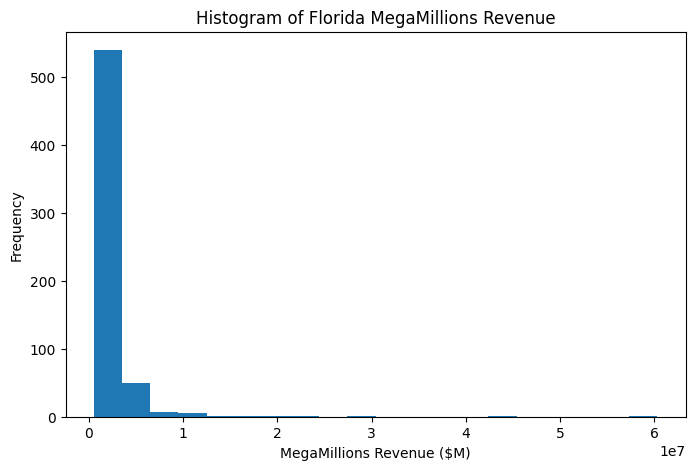

In [26]:
# histogram - show revenue distribution 
plt.figure(figsize=(8,5))
plt.hist(df["revenue($)"],bins=20)
plt.xlabel("MegaMillions Revenue ($M)")
plt.ylabel("Frequency")
plt.title("Histogram of Florida MegaMillions Revenue")
plt.show()

Florida MegaMillions revenue is heavily right-skewed. Most observations are below $5 million, while the mean ($2.56 million) exceeds the median ($1.87 million) and the maximum reaches $60.35 million. This indicates extreme high-revenue outliers and supports using a log transformation before modeling.

<br>

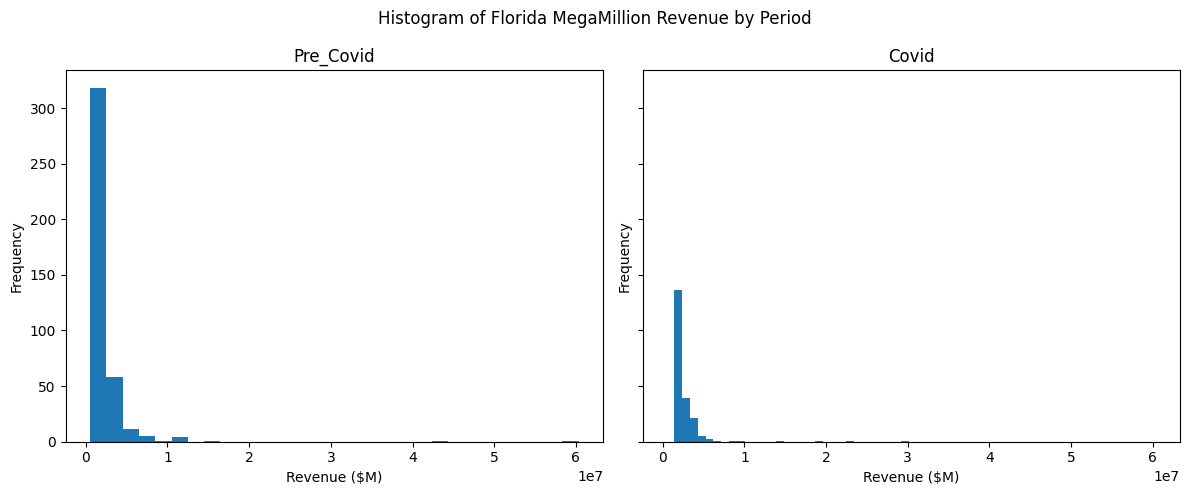

In [27]:
# histogram of revenue by periods for comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Pre-Covid
axes[0].hist(df.loc[df["covid"] == 0, "revenue($)"], bins=30)
axes[0].set_title("Pre_Covid")
axes[0].set_xlabel("Revenue ($M)")
axes[0].set_ylabel("Frequency")

# Covid
axes[1].hist(df.loc[df["covid"] == 1, "revenue($)"], bins=30)
axes[1].set_title("Covid")
axes[1].set_xlabel("Revenue ($M)")
axes[1].set_ylabel("Frequency")

plt.suptitle("Histogram of Florida MegaMillion Revenue by Period")
plt.tight_layout()
plt.show()

Florida MegaMillions revenue is heavily right-skewed in both the Pre_Covid and Covid periods. The centers of the two distributions appear fairly similar, but the Covid period has fewer observations and fewer extremely large revenue values. This suggests that Florida MegaMillions revenue remained similarly centered across periods, while the frequency of draws and the occurrence of very high-revenue observations were lower during Covid.

<br>

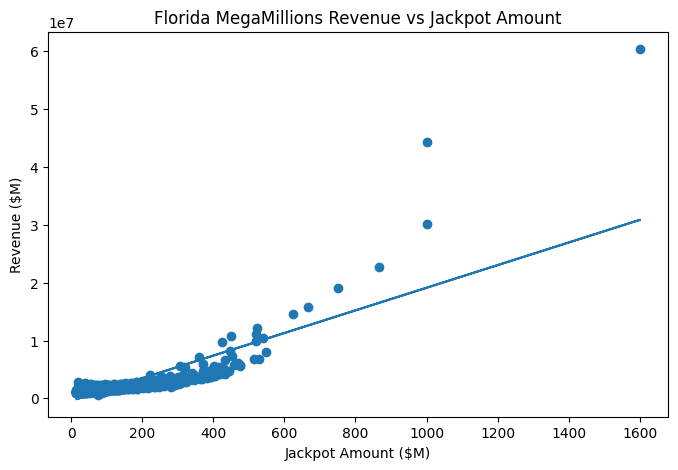

In [28]:
# scatter plot - show how revenue changes as the amount of jackpot changes

plt.figure(figsize=(8,5))
plt.scatter(df["jackpot_amount($)"],df["revenue($)"])

m,b = np.polyfit(df["jackpot_amount($)"], df["revenue($)"],1)
plt.plot(df["jackpot_amount($)"], m*df["jackpot_amount($)"]+b)

plt.xlabel("Jackpot Amount ($M)")
plt.ylabel("Revenue ($M)")
plt.title("Florida MegaMillions Revenue vs Jackpot Amount")
plt.show()

The scatter plot for Florida MegaMillions suggests a positive association between jackpot amount and revenue: as the jackpot amount increases, MegaMillions revenue also tends to increase. The relationship is roughly linear overall, although the spread in revenue becomes wider at higher jackpot amounts, indicating greater variability for large jackpots. The plot also shows several high-revenue outliers, including an extreme observation above $60 million associated with a jackpot near $1.6 billion.

<br>

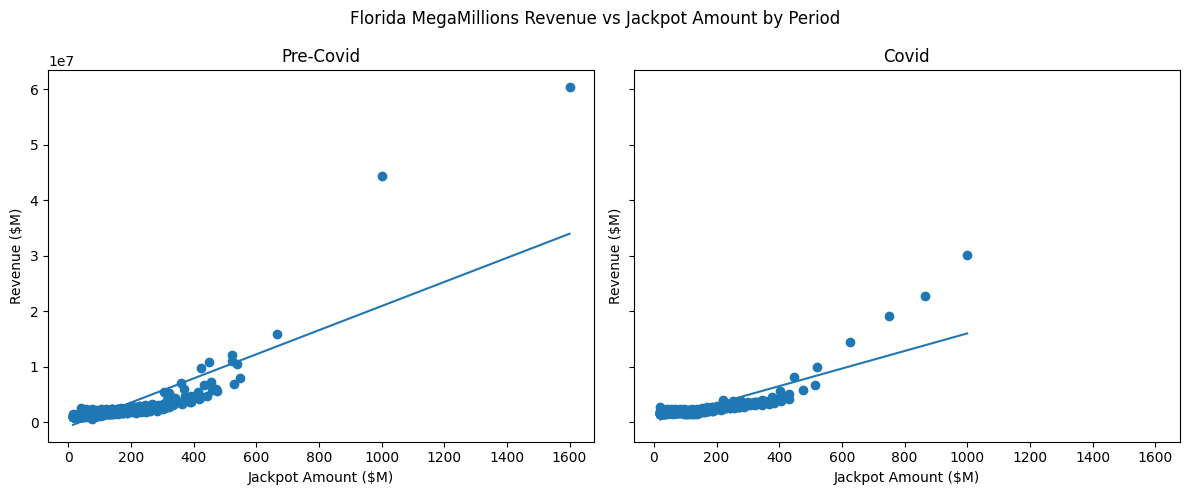

In [30]:
# set the same scale for both scatter plots and regression lines 
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Pre-Covid
x_pre = df.loc[df["covid"] == 0, "jackpot_amount($)"] # locate the covid==0 rows, and take the corresponding jackpot 
y_pre = df.loc[df["covid"] == 0, "revenue($)"] # locate the covid==0 rows, and take the corresponding revenues 

axes[0].scatter(x_pre, y_pre)
slope_pre, intercept_pre = np.polyfit(x_pre, y_pre, 1)
x_pre_sorted = np.sort(x_pre)
axes[0].plot(x_pre_sorted, slope_pre * x_pre_sorted + intercept_pre)
axes[0].set_title("Pre-Covid")
axes[0].set_xlabel("Jackpot Amount ($M)")
axes[0].set_ylabel("Revenue ($M)")

# Covid
x_covid = df.loc[df["covid"] == 1, "jackpot_amount($)"]
y_covid = df.loc[df["covid"] == 1, "revenue($)"]

axes[1].scatter(x_covid, y_covid)
slope_covid, intercept_covid = np.polyfit(x_covid, y_covid, 1)
x_covid_sorted = np.sort(x_covid)
axes[1].plot(x_covid_sorted, slope_covid * x_covid_sorted + intercept_covid)
axes[1].set_title("Covid")
axes[1].set_xlabel("Jackpot Amount ($M)")
axes[1].set_ylabel("Revenue ($M)")

plt.suptitle("Florida MegaMillions Revenue vs Jackpot Amount by Period")
plt.tight_layout() # adjust spacing automatically (e.g., prevents title overlapping..)
plt.show()

The scatter plots for Florida MegaMillions suggest a positive relationship between revenue and jackpot amount in both periods. The fitted line is steeper in the Pre-Covid period than in the Covid period, indicating that MegaMillions revenue may have been more responsive to jackpot increases before Covid. The plots also suggest that, for comparable jackpot levels, MegaMillions revenue tended to be somewhat lower during Covid than before Covid.

<br>

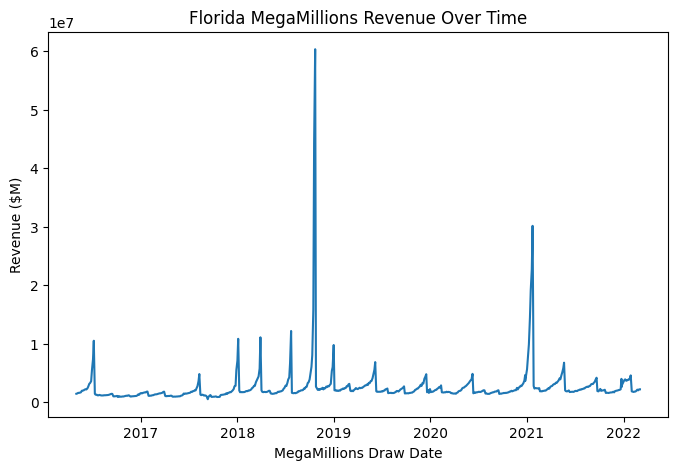

In [31]:
# line plot - show how revenues change over time 
plt.figure(figsize=(8,5))
plt.plot(df["draw_date"],df["revenue($)"])
plt.xlabel("MegaMillions Draw Date")
plt.ylabel("Revenue ($M)")
plt.title("Florida MegaMillions Revenue Over Time")
plt.show()

The line plot for Florida MegaMillions revenue shows substantial fluctuation over time, with several sharp spikes corresponding to unusually high-revenue draws. Revenue appears lower and less volatile during parts of the Covid period, especially in 2020, before rising again afterward. The plot also shows extreme revenue outliers, including a very large spike in late 2018 exceeding $60 million and another major spike in early 2021 around $30 million.

<br>

<Figure size 800x500 with 0 Axes>

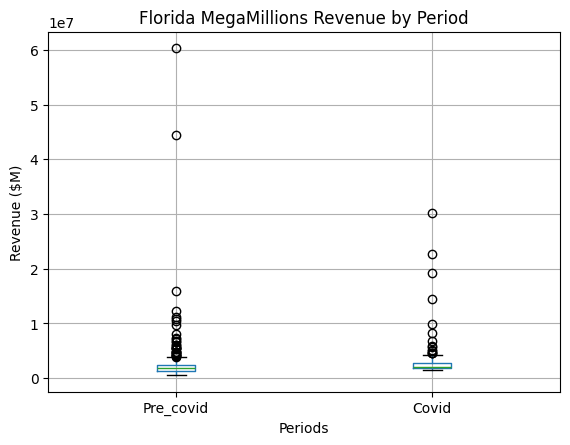

In [32]:
# boxplot 
# define a new variable "covid_label" - using map() -  covid_period =0 as "Pre_covid" and =1 as "Covid"
# pre_covid: May 04,2016 - March 03,2020; covid: March 04,2020 - March 07, 2022 
# May 04, 2016 is the earliest date lottery information could be found online and March 07 is the day this project began.
df["covid_label"] = pd.Categorical(
    df["covid_period"].map({0:"Pre_covid", 1:"Covid"}),
    categories=["Pre_covid", "Covid"],
    ordered=True
) # used pd.Categorical() to treat "covid_label" as categorical and not ordinal; ordered=True ensures Pre_covid is in front of Covid

plt.figure(figsize=(8,5))
df.boxplot(column = "revenue($)", by="covid_label")

plt.title("Florida MegaMillions Revenue by Period")
plt.suptitle("") # to clean the auto title 
plt.xlabel("Periods")
plt.ylabel("Revenue ($M)")
plt.show()

The boxplot shows that Florida MegaMillions revenue had fairly similar medians in the Pre_Covid and Covid periods, with the Covid period appearing slightly higher. Both periods contain numerous high-revenue outliers, indicating substantial right skewness. The Pre_Covid period includes the most extreme outlier, exceeding $60 million, while the largest Covid outlier is around $30 million. This suggests that MegaMillions revenue was similarly centered across periods, but the most extreme high-revenue draws occurred before Covid.

<br>

### Correlation Coefficients

In [49]:
# correlation coefficient tests on revenue and jackpot amount 
# Pearson's p and Spearman Rank Order Correlation 
print("Pearson's Correlation:")
print(df[["jackpot_amount($)","revenue($)"]].corr(method="pearson"))

print("Spearman's Correlation:")
print(df[["jackpot_amount($)","revenue($)"]].corr(method="spearman"))

Pearson's Correlation:
                   jackpot_amount($)  revenue($)
jackpot_amount($)           1.000000    0.770158
revenue($)                  0.770158    1.000000
Spearman's Correlation:
                   jackpot_amount($)  revenue($)
jackpot_amount($)           1.000000    0.754274
revenue($)                  0.754274    1.000000


Both the Pearson and Spearman correlations show a strong positive association between revenues and jackpot amount, suggesting that the positive relationship is stable, even though the data still show skewness and outliers.

<br>

All graphs and summary statistics indicate that the data is heavily right-skewed and contains several extremely high-value revenue outliers. To ensure a robust model, I will analyze these outliers before building the models.

# Outlier Detection for Revenues
### 3 standard deviation rule 
### Hampel Identifier
### IQR - already done above

In [45]:
# 3 standard deviation rule 
mean_revenue = df["revenue($)"].mean()
std_revenue = df["revenue($)"].std()

lower_3std = mean_revenue - 3*std_revenue
upper_3std = mean_revenue + 3*std_revenue

outliers_std = df[(df["revenue($)"]<lower_3std)|(df["revenue($)"]>upper_3std)]

print("3 Standard Deviation Rule:")
print("Lower Bound:", lower_3std)
print("Upper Bound:", upper_3std)
print("Number of Outliers", outliers_std.shape[0])

print(outliers_std[["draw_date","jackpot_amount($)","revenue($)"]])

3 Standard Deviation Rule:
Lower Bound: -5301954.524133937
Upper Bound: 12939495.2252294
Number of Outliers 19
     draw_date  jackpot_amount($)  revenue($)
1   2016-05-07                415    13609322
84  2017-02-22                403    13402222
115 2017-06-10                435    14571695
135 2017-08-19                535    19784137
136 2017-08-23                700    38121888
174 2018-01-03                460    14426212
175 2018-01-06                570    21000850
257 2018-10-20                470    16881580
258 2018-10-24                620    20998301
259 2018-10-27                750    15218359
300 2019-03-20                550    13206588
301 2019-03-23                625    17092799
302 2019-03-27                750    25053314
490 2021-01-13                550    14818294
491 2021-01-16                640    18767788
492 2021-01-20                730    20568410
571 2021-10-02                635    14220380
610 2022-01-01                500    13299894
612 2022-01-05 

19 rows of outliers are detected. Since the outlier proportion is about 3% (above the 1% 3std rule threshold), a Hampel comparison is considered.

In [53]:
# hampel identifier 
    ## the hampel use median and MAD is the core part
# MAD:
    ## first calculate the absolute deviation: abs(revenues - median_revenue)
    ## then take the median of those absolute deviations

# Hampel score:
    ## absolute deviation divided by (1.4826 * MAD)
median_revenue = df["revenue($)"].median()

MAD = np.median(np.abs(df["revenue($)"]-median_revenue))

hampel_score = np.abs(df["revenue($)"]-median_revenue)/(1.4826*MAD)

outliers_hampel = df[hampel_score>3]

print("Hample Outliers:")
print("Median:", median_revenue)
print("MAD:", MAD)
print("Number of Outliers:", outliers_hampel.shape[0])

print(outliers_hampel[["draw_date","jackpot_amount($)","revenue($)"]])

Hample Outliers:
Median: 3082460.0
MAD: 578479.0
Number of Outliers: 58
     draw_date  jackpot_amount($)  revenue($)
0   2016-05-04                348     7808170
1   2016-05-07                415    13609322
23  2016-07-23                390     6267968
24  2016-07-27                422     8896557
25  2016-07-30                478    12323899
57  2016-11-19                320     5910739
58  2016-11-23                359     7442138
59  2016-11-26                403     9676470
81  2017-02-11                285     5698628
82  2017-02-15                310     6625618
83  2017-02-18                349     8052517
84  2017-02-22                403    13402222
113 2017-06-03                337     7785283
114 2017-06-07                375     8988990
115 2017-06-10                435    14571695
132 2017-08-09                307     6182888
133 2017-08-12                356     9128994
134 2017-08-16                430    11196495
135 2017-08-19                535    19784137
136 2017

Hampel detected 58 outlier rows, which is substantially higher than the 3 standard deviation rule. Given the right-skewed distribution of the data, this suggests that the 3 standard deviation rule may be influenced by extreme values because it depends on the mean and standard deviation. The IQR method will be considered next.

In [54]:
# IQR
Q1 = df["revenue($)"].quantile(0.25)
Q3 = df["revenue($)"].quantile(0.75)
IQR = Q3-Q1

lower_IQR = Q1 - 1.5*IQR
upper_IQR = Q3 + 1.5*IQR

outliers_IQR = df[(df["revenue($)"]<lower_IQR)|(df["revenue($)"]>upper_IQR)]

print("Interquartile Range (IQR) Outliers:")
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_IQR)
print("Upper Bound:", upper_IQR)
print("Number of Outliers:", outliers_IQR.shape[0])

print(outliers_IQR[["draw_date","jackpot_amount($)","revenue($)"]])

Interquartile Range (IQR) Outliers:
Q1: 2568074.0
Q3: 3768981.0
IQR: 1200907.0
Lower Bound: 766713.5
Upper Bound: 5570341.5
Number of Outliers: 61
     draw_date  jackpot_amount($)  revenue($)
0   2016-05-04                348     7808170
1   2016-05-07                415    13609322
19  2016-07-09                288     5612586
23  2016-07-23                390     6267968
24  2016-07-27                422     8896557
..         ...                ...         ...
607 2021-12-25                441     7518389
609 2021-12-29                400     6116661
610 2022-01-01                500    13299894
611 2022-01-03                540    10055296
612 2022-01-05                630    15981253

[61 rows x 3 columns]


IQR detected 61 outliers, which is very similar to the Hampel identifier (58). This suggests that for this right skewed variable, the 3 std method is influenced by large outliers. Therefore the more robust methods IQR and Hampel appear to be more appropriate for detecting outliers. 
This means that the data are not well behaved enough to rely on the mean-based rule; therefore, when modeling, a more robust approach is preferred such as using "log revenue" instead of the raw dollar valued "revenue($) as the target variable.

<br>

# Create a Log Transformed Target Variable:
### log_revenue

In [46]:
# use log transformation to reduce the skewness of the data
df["log_revenue"] = np.log(df["revenue($)"])

In [47]:
print(df["log_revenue"].describe())

count    639.000000
mean      15.018417
std        0.447261
min       14.179552
25%       14.758667
50%       14.941239
75%       15.142315
max       17.456299
Name: log_revenue, dtype: float64


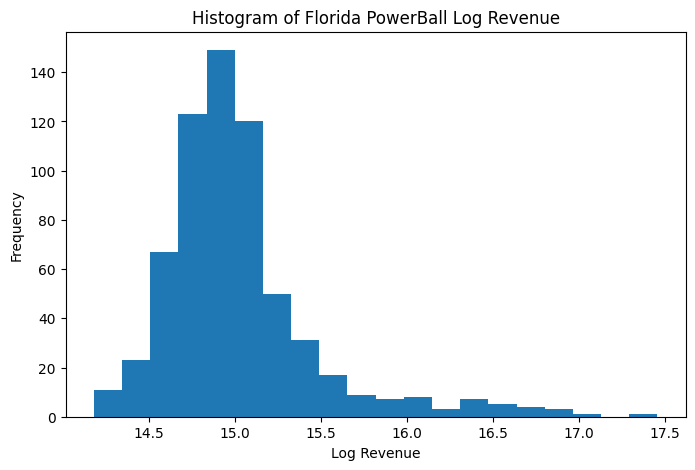

In [48]:
# log_revenue histogram 
plt.figure(figsize=(8,5))
plt.hist(df["log_revenue"],bins=20)
plt.xlabel("Log Revenue")
plt.ylabel("Frequency")
plt.title("Histogram of Florida PowerBall Log Revenue")
plt.show()


After the log transformation, the distribution of revenue becomes more symmetric and closer to a normal distribution, although some right skew remains.

<br>

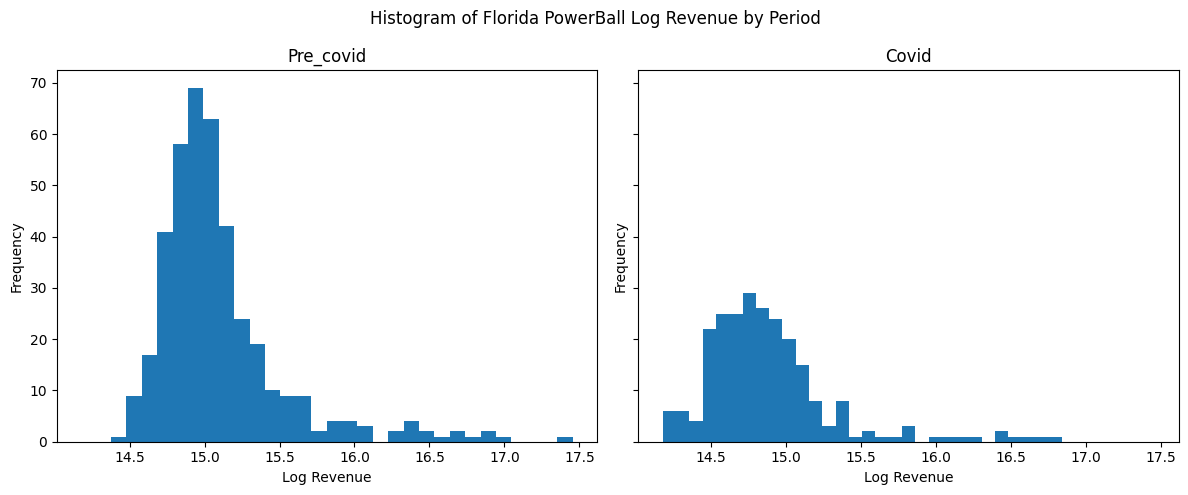

In [49]:
# histogram of log revenue by periods for comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Pre-Covid
axes[0].hist(df.loc[df["covid"] == 0, "log_revenue"], bins=30)
axes[0].set_title("Pre_covid")
axes[0].set_xlabel("Log Revenue")
axes[0].set_ylabel("Frequency")

# Covid
axes[1].hist(df.loc[df["covid"] == 1, "log_revenue"], bins=30)
axes[1].set_title("Covid")
axes[1].set_xlabel("Log Revenue")
axes[1].set_ylabel("Frequency")

plt.suptitle("Histogram of Florida PowerBall Log Revenue by Period")
plt.tight_layout()
plt.show()

After the log transformation, both the Pre_covid and Covid distributions are less right-skewed and closer to normal. However, the Pre_covid period still shows a slightly wider spread and more high log-revenue observations, while the Covid period appears more concentrated at lower log-revenue values with fewer extreme high values. This suggests that PowerBall revenue was generally lower and less variable during Covid.

<br>

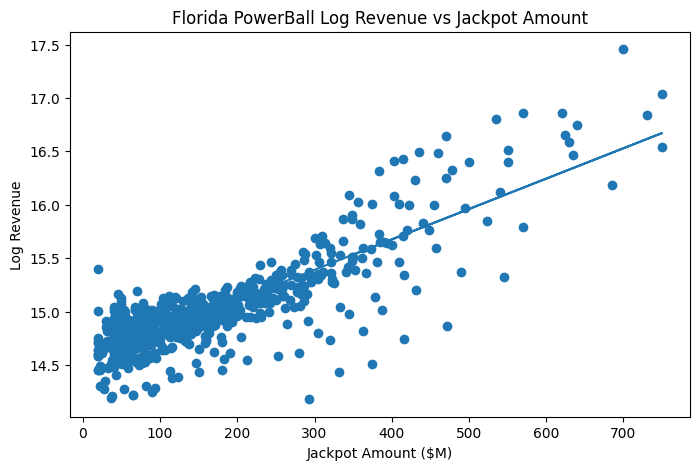

In [50]:
# log scatter plot - show how log revenue changes as the amount of jackpot changes

plt.figure(figsize=(8,5))
plt.scatter(df["jackpot_amount($)"],df["log_revenue"])

m,b = np.polyfit(df["jackpot_amount($)"], df["log_revenue"],1)
plt.plot(df["jackpot_amount($)"], m*df["jackpot_amount($)"]+b)

plt.xlabel("Jackpot Amount ($M)")
plt.ylabel("Log Revenue")
plt.title("Florida PowerBall Log Revenue vs Jackpot Amount")
plt.show()

The scatter plot shows a clear positive association between jackpot amount and log revenue. As the jackpot increases, log revenue generally increases as well, indicating that larger jackpots are associated with higher PowerBall revenue.

<br>

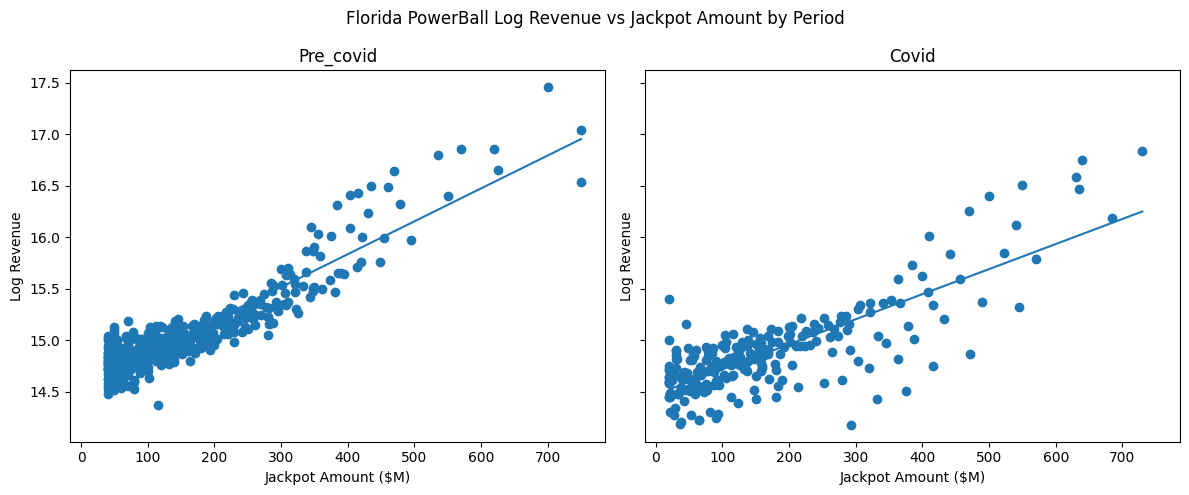

In [51]:
# compare scatter plots of log revenue between periods

# set the same scale for both scatter plots and regression lines 
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Pre-Covid
x_pre = df.loc[df["covid"] == 0, "jackpot_amount($)"] # locate the covid==0 rows, and take the corresponding jackpot 
y_pre = df.loc[df["covid"] == 0, "log_revenue"] # locate the covid==0 rows, and take the corresponding revenues 

axes[0].scatter(x_pre, y_pre)
slope_pre, intercept_pre = np.polyfit(x_pre, y_pre, 1)
x_pre_sorted = np.sort(x_pre)
axes[0].plot(x_pre_sorted, slope_pre * x_pre_sorted + intercept_pre)
axes[0].set_title("Pre_covid")
axes[0].set_xlabel("Jackpot Amount ($M)")
axes[0].set_ylabel("Log Revenue")

# Covid
x_covid = df.loc[df["covid"] == 1, "jackpot_amount($)"]
y_covid = df.loc[df["covid"] == 1, "log_revenue"]

axes[1].scatter(x_covid, y_covid)
slope_covid, intercept_covid = np.polyfit(x_covid, y_covid, 1)
x_covid_sorted = np.sort(x_covid)
axes[1].plot(x_covid_sorted, slope_covid * x_covid_sorted + intercept_covid)
axes[1].set_title("Covid")
axes[1].set_xlabel("Jackpot Amount ($M)")
axes[1].set_ylabel("Log Revenue")

plt.suptitle("Florida PowerBall Log Revenue vs Jackpot Amount by Period")
plt.tight_layout() # adjust spacing automatically (e.g., prevents title overlapping..)
plt.show()

In both the Pre_covid and Covid periods, jackpot amount shows a positive association with log revenue. However, the positive relationship appears somewhat stronger and more consistent in the Pre_covid period, while the Covid period shows greater scatter around the trend line. This suggests that larger jackpots were associated with higher PowerBall revenue in both periods, but the relationship was less stable during Covid.

<br>

# Preparation for Building Regression Models
### Check correlation and create new variables

In [52]:
# check the correlation of variables to avoid multicollinearity 

# unemployment rate and adjusted unemployment rate
print("Correlation Between Unemployment Rate and Adjusted Unemployment Rate")
print(df[["unemployment_rate_adjusted","unemployment_rate"]].corr())

Correlation Between Unemployment Rate and Adjusted Unemployment Rate
                            unemployment_rate_adjusted  unemployment_rate
unemployment_rate_adjusted                    1.000000           0.994629
unemployment_rate                             0.994629           1.000000


Since the unemployment rate has extremely high correlation with the adjusted unemployment rate, use only one (unemployment_rate) in the models.

In [53]:
# create "lag_jackpot($)" - each row uses the previous drawing's jackpot amount
# sort by draw_date before creating lag variables
df = df.sort_values("draw_date").reset_index(drop=True)

df["lag_jackpot($)"] = df["jackpot_amount($)"].shift(1)

In [ ]:
# create a lagjackpot squared term to allow nonlinear effect of jackpot on revenue but ended up not using it
# df["lagjackpot_squared"] = df["lagjackpot"]**2

In [54]:
# create interaction terms: "lag_jackpot_covid", "unemployment_rate_covid", and "lag_jackpot_unemployment_rate"
df["lag_jackpot($)_covid"] = df["lag_jackpot($)"]*df["covid"]
df["unemployment_rate_covid"] = df["unemployment_rate"]*df["covid"]
df["lag_jackpot($)_unemployment_rate"] = df["lag_jackpot($)"]*df["unemployment_rate"]

In [55]:
# create year dummies 
df["year"] = np.nan

df.loc[df["year2016"] == 1, "year"] = 2016
df.loc[df["year2017"] == 1, "year"] = 2017
df.loc[df["year2018"] == 1, "year"] = 2018
df.loc[df["year2019"] == 1, "year"] = 2019
df.loc[df["year2020"] == 1, "year"] = 2020
df.loc[df["year2021"] == 1, "year"] = 2021
df.loc[df["year2022"] == 1, "year"] = 2022

<br>

# Build 3 Regression Models

In [56]:
# check variables again 
print(df.columns)

Index(['draw_date', 'revenue($)', 'jackpot_amount($)', 'covid', 'covid_cases',
       'monday', 'wednesday', 'unemployment_rate_adjusted',
       'unemployment_rate', 'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul',
       'aug', 'sept', 'oct', 'nov', 'year2016', 'year2017', 'year2018',
       'year2019', 'year2020', 'year2021', 'year2022', 'covid_period',
       'log_revenue', 'lag_jackpot($)', 'lag_jackpot($)_covid',
       'unemployment_rate_covid', 'lag_jackpot($)_unemployment_rate', 'year'],
      dtype='object')


In [60]:
# Model 1
# since lagjackpot was created using "shift1", the first row may be empty and it needs to be dropped 

model_vars_1 = ["log_revenue", "covid", "lag_jackpot($)", "unemployment_rate", "monday", "wednesday"]
df1 = df[model_vars_1].dropna()

# choose predictors and target variable
X1 = df1[["covid","lag_jackpot($)","unemployment_rate","monday","wednesday"]]
X1 = sm.add_constant(X1)
y = df1["log_revenue"]

# fit the model
model1 = sm.OLS(y,X1).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.605
Model:                            OLS   Adj. R-squared:                  0.602
Method:                 Least Squares   F-statistic:                     193.9
Date:                Wed, 01 Apr 2026   Prob (F-statistic):          5.01e-125
Time:                        12:35:34   Log-Likelihood:                -93.509
No. Observations:                 638   AIC:                             199.0
Df Residuals:                     632   BIC:                             225.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                14.8113      0.03

In [61]:
# Model 2
# since lagjackpot was created using "shift1", the first row may be empty and it needs to be dropped 
model_vars_2 = ["log_revenue", "covid", "lag_jackpot($)", "lag_jackpot($)_covid","unemployment_rate", "unemployment_rate_covid","monday", "wednesday"]
df2 = df[model_vars_2].dropna()

# choose predictors and target variable
X2 = df2[["covid","lag_jackpot($)","lag_jackpot($)_covid","unemployment_rate","unemployment_rate_covid","monday","wednesday"]]
X2 = sm.add_constant(X2)
y = df2["log_revenue"]

# fit the model
model2 = sm.OLS(y,X2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.619
Model:                            OLS   Adj. R-squared:                  0.615
Method:                 Least Squares   F-statistic:                     146.5
Date:                Wed, 01 Apr 2026   Prob (F-statistic):          1.11e-127
Time:                        12:36:38   Log-Likelihood:                -81.929
No. Observations:                 638   AIC:                             179.9
Df Residuals:                     630   BIC:                             215.5
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [62]:
# Model 3
# since lagjackpot was created using "shift1", the first row may be empty and it needs to be dropped 

model_vars_3 = ["log_revenue", "covid", "lag_jackpot($)", "lag_jackpot($)_covid","unemployment_rate", "unemployment_rate_covid","lag_jackpot($)_unemployment_rate","monday", "wednesday"]
df3 = df[model_vars_3].dropna()

# choose predictors and target variable
X3 = df3[["covid","lag_jackpot($)","lag_jackpot($)_covid","unemployment_rate","unemployment_rate_covid","lag_jackpot($)_unemployment_rate","monday","wednesday"]]
X3 = sm.add_constant(X3)
y = df3["log_revenue"]

# fit the model
model3 = sm.OLS(y,X3).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.621
Model:                            OLS   Adj. R-squared:                  0.616
Method:                 Least Squares   F-statistic:                     128.9
Date:                Wed, 01 Apr 2026   Prob (F-statistic):          3.22e-127
Time:                        12:37:48   Log-Likelihood:                -80.432
No. Observations:                 638   AIC:                             178.9
Df Residuals:                     629   BIC:                             219.0
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

<br>

# Compare the models 
### AIC, BIC, Adjusted-R^2

In [63]:
model_comparison_table = pd.DataFrame({
    "Model": ["Model 1", "Model 2", "Model 3"],
    "n_obs": [model1.nobs, model2.nobs, model3.nobs],
    "R_squared": [model1.rsquared, model2.rsquared, model3.rsquared],
    "Adj_R_squared": [model1.rsquared_adj, model2.rsquared_adj, model3.rsquared_adj],
    "AIC": [model1.aic, model2.aic, model3.aic],
    "BIC": [model1.bic, model2.bic, model3.bic]
})

model_comparison_table

,Model,n_obs,R_squared,Adj_R_squared,AIC,BIC
0,Model 1,638.0,0.605368,0.602246,199.018837,225.768867
1,Model 2,638.0,0.619437,0.615209,179.858604,215.525311
2,Model 3,638.0,0.621220,0.616402,178.863324,218.988369


Conclusion: Among the three candidate models, Model 3 was selected as the final model. It has the highest adjusted R-squared and the lowest AIC, indicating the strongest overall fit to the data. Although Model 2 has the lowest BIC and is therefore the more parsimonious model, Model 3 was preferred because it provides the best balance of explanatory power and model fit.

<br>

In [66]:
def linear_combination_test(results, weights_dict, label="Quantity"):
    parameter_names = results.params.index
    weight_vector = pd.Series(0.0, index=parameter_names)

    for name, weight in weights_dict.items():
        weight_vector[name] = weight

    test_result = results.t_test(weight_vector.values)

    estimate = test_result.effect.item()
    standard_error = test_result.sd.item()
    t_value = test_result.tvalue.item()
    p_value = test_result.pvalue.item()
    ci_lower, ci_upper = test_result.conf_int()[0]

    output = pd.DataFrame({
        "Quantity": [label],
        "Estimate": [estimate],
        "Std_Error": [standard_error],
        "t_value": [t_value],
        "p_value": [p_value],
        "CI_Lower_95": [ci_lower],
        "CI_Upper_95": [ci_upper]
    })

    return output


# sample means used in Model 3 interpretation
mean_jackpot_3 = df3["lag_jackpot($)"].mean()
mean_unempr_3 = df3["unemployment_rate"].mean()
mean_monday_3 = df3["monday"].mean()
mean_wednesday_3 = df3["wednesday"].mean()

# interaction evaluated at the sample means
mean_interaction_3 = mean_jackpot_3 * mean_unempr_3


# 1) predicted mean log revenue before Covid
predicted_mean_before_weights = {
    "const": 1,
    "lag_jackpot($)": mean_jackpot_3,
    "unemployment_rate": mean_unempr_3,
    "lag_jackpot($)_unemployment_rate": mean_interaction_3,
    "monday": mean_monday_3,
    "wednesday": mean_wednesday_3
}

predicted_mean_before_result = linear_combination_test(
    model3,
    predicted_mean_before_weights,
    label="Predicted Mean Log Revenue Before Covid"
)


# 2) predicted mean log revenue during Covid
predicted_mean_during_weights = {
    "const": 1,
    "covid": 1,
    "lag_jackpot($)": mean_jackpot_3,
    "lag_jackpot($)_covid": mean_jackpot_3,
    "unemployment_rate": mean_unempr_3,
    "unemployment_rate_covid": mean_unempr_3,
    "lag_jackpot($)_unemployment_rate": mean_interaction_3,
    "monday": mean_monday_3,
    "wednesday": mean_wednesday_3
}

predicted_mean_during_result = linear_combination_test(
    model3,
    predicted_mean_during_weights,
    label="Predicted Mean Log Revenue During Covid"
)


# 3) difference in predicted mean log revenue (during - before)
difference_in_predicted_mean_weights = {
    "covid": 1,
    "lag_jackpot($)_covid": mean_jackpot_3,
    "unemployment_rate_covid": mean_unempr_3
}

difference_in_predicted_mean_result = linear_combination_test(
    model3,
    difference_in_predicted_mean_weights,
    label="Difference in Predicted Mean Log Revenue (during - before)"
)


# 4) marginal effect of lagged jackpot before Covid
marginal_effect_lagjackpot_before_weights = {
    "lag_jackpot($)": 1,
    "lag_jackpot($)_unemployment_rate": mean_unempr_3
}

marginal_effect_lagjackpot_before_result = linear_combination_test(
    model3,
    marginal_effect_lagjackpot_before_weights,
    label="Marginal Effect of Lagged Jackpot Before Covid"
)


# 5) marginal effect of lagged jackpot during Covid
marginal_effect_lagjackpot_during_weights = {
    "lag_jackpot($)": 1,
    "lag_jackpot($)_covid": 1,
    "lag_jackpot($)_unemployment_rate": mean_unempr_3
}

marginal_effect_lagjackpot_during_result = linear_combination_test(
    model3,
    marginal_effect_lagjackpot_during_weights,
    label="Marginal Effect of Lagged Jackpot During Covid"
)


# 6) difference in marginal effect of lagged jackpot
difference_in_marginal_effect_lagjackpot_weights = {
    "lag_jackpot($)_covid": 1
}

difference_in_marginal_effect_lagjackpot_result = linear_combination_test(
    model3,
    difference_in_marginal_effect_lagjackpot_weights,
    label="Difference in Marginal Effect of Lagged Jackpot"
)


# 7) marginal effect of unemployment rate before Covid
marginal_effect_unempr_before_weights = {
    "unemployment_rate": 1,
    "lag_jackpot($)_unemployment_rate": mean_jackpot_3
}

marginal_effect_unempr_before_result = linear_combination_test(
    model3,
    marginal_effect_unempr_before_weights,
    label="Marginal Effect of Unemployment Rate Before Covid"
)


# 8) marginal effect of unemployment rate during Covid
marginal_effect_unempr_during_weights = {
    "unemployment_rate": 1,
    "unemployment_rate_covid": 1,
    "lag_jackpot($)_unemployment_rate": mean_jackpot_3
}

marginal_effect_unempr_during_result = linear_combination_test(
    model3,
    marginal_effect_unempr_during_weights,
    label="Marginal Effect of Unemployment Rate During Covid"
)


# 9) difference in marginal effect of unemployment rate
difference_in_marginal_effect_unempr_weights = {
    "unemployment_rate_covid": 1
}

difference_in_marginal_effect_unempr_result = linear_combination_test(
    model3,
    difference_in_marginal_effect_unempr_weights,
    label="Difference in Marginal Effect of Unemployment Rate"
)


# combine all post-estimation results into one table
model3_post_estimation_table = pd.concat([
    predicted_mean_before_result,
    predicted_mean_during_result,
    difference_in_predicted_mean_result,
    marginal_effect_lagjackpot_before_result,
    marginal_effect_lagjackpot_during_result,
    difference_in_marginal_effect_lagjackpot_result,
    marginal_effect_unempr_before_result,
    marginal_effect_unempr_during_result,
    difference_in_marginal_effect_unempr_result
], ignore_index=True)

model3_post_estimation_table

,Quantity,Estimate,Std_Error,t_value,p_value,CI_Lower_95,CI_Upper_95
0,Predicted Mean Log Revenue Before Covid,15.139813,0.021544,702.740866,0.000000e+00,15.097506,15.182120
1,Predicted Mean Log Revenue During Covid,14.950773,0.020865,716.551639,0.000000e+00,14.909800,14.991747
2,Difference in Predicted Mean Log Revenue (duri...,-0.189040,0.030538,-6.190402,1.082847e-09,-0.249008,-0.129072
3,Marginal Effect of Lagged Jackpot Before Covid,0.002513,0.000124,20.208463,2.326641e-70,0.002269,0.002757
4,Marginal Effect of Lagged Jackpot During Covid,0.002188,0.000129,16.914829,3.511337e-53,0.001934,0.002442
5,Difference in Marginal Effect of Lagged Jackpot,-0.000325,0.000179,-1.816483,6.977221e-02,-0.000676,0.000026
6,Marginal Effect of Unemployment Rate Before Covid,0.080134,0.019890,4.028936,6.288581e-05,0.041076,0.119192
7,Marginal Effect of Unemployment Rate During Covid,-0.008868,0.007939,-1.116934,2.644492e-01,-0.024458,0.006723
8,Difference in Marginal Effect of Unemployment ...,-0.089002,0.021386,-4.161649,3.599620e-05,-0.130998,-0.047005


Conclusion: Holding the other variables at their sample means, predicted log revenue declined from 15.140 before Covid to 14.951 during Covid. On the original scale, this corresponds to a decline in predicted revenue from about $3.77 million to $3.11 million, or about 17.2%. The marginal effect of lagged jackpot remained positive in both periods: a $1 million increase in lagged jackpot was associated with about a 0.25% increase in revenue before Covid and about a 0.22% increase during Covid, with no statistically significant difference between periods. The unemployment-rate effect, however, changed substantially: before Covid, a one-unit increase in unemployment rate was associated with about an 8.3% increase in revenue, whereas during Covid the effect was small, negative, and not statistically significant. Overall, the results indicate that PowerBall revenue was lower during Covid, the positive jackpot effect persisted, and the unemployment-rate effect weakened notably during the Covid period.C